In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
path_to_data = '/content/drive/MyDrive/CEMS'
print(os.listdir(path_to_data))


Mounted at /content/drive
['EMSR468', 'EMSR466', 'EMSR352', 'EMSN194', 'EMSR417', 'EMSR339', 'EMSR416']


In [2]:
!pip install torch torchvision
!pip install rasterio  # for handling .tif images
!pip install albumentations  # for data augmentation


In [3]:
from torch.cuda.amp import autocast, GradScaler
scaler = GradScaler()

/tmp/ipython-input-2736003858.py:2: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [4]:
import os
import numpy as np
import torch
import rasterio
from torch.utils.data import Dataset

class SenForFloodEventDataset(Dataset):
    def __init__(self, root_dir, modalities, patch_size=512,
                 random_crop=True, transforms=None, flood_threshold=0.1):
        self.root_dir = root_dir
        self.modalities = modalities
        self.patch_size = patch_size
        self.random_crop = random_crop
        self.transforms = transforms
        self.flood_threshold = flood_threshold  # New parameter to filter based on flood area percentage

        self.index = []  # list of (event_id, sample_id)

        # Go through all events
        events = sorted([f for f in os.listdir(root_dir)
                         if os.path.isdir(os.path.join(root_dir, f))])

        for event in events:
            before_path = os.path.join(root_dir, event, "s1_before_flood")
            tif_files = sorted([f for f in os.listdir(before_path)
                                if f.endswith(".tif")])

            # Extract sample prefixes: 00001 from 00001_s1_before_flood.tif
            sample_ids = [f.split("_")[0] for f in tif_files]

            for sid in sample_ids:
                self.index.append((event, sid))

    def __len__(self):
        return len(self.index)

    def load_raster(self, event, folder, sample_id):
        folder_path = os.path.join(self.root_dir, event, folder)
        file = [f for f in os.listdir(folder_path)
                if f.startswith(sample_id)]
        if len(file) != 1:
            raise RuntimeError(f"Missing file for {event} {folder} {sample_id}")

        path = os.path.join(folder_path, file[0])
        with rasterio.open(path) as src:
            return src.read()

    def crop(self, img, mask):
        _, H, W = img.shape
        ph = self.patch_size

        if self.random_crop:
            top = np.random.randint(0, H - ph)
            left = np.random.randint(0, W - ph)
        else:
            top = (H - ph) // 2
            left = (W - ph) // 2

        return (img[:, top:top+ph, left:left+ph],
                mask[:, top:top+ph, left:left+ph])

    def calculate_flood_area_percentage(self, mask):
        # Calculate the percentage of flooded area in the mask
        flood_area = np.sum(mask > 0)
        total_area = mask.size
        return flood_area / total_area

    def __getitem__(self, idx):
        event, sid = self.index[idx]

        # Load modalities
        arrays = []
        for folder in self.modalities:
            arrays.append(self.load_raster(event, folder, sid))
        x = np.concatenate(arrays, axis=0)

        # Load mask
        y = self.load_raster(event, "flood_mask", sid)
        y = (y > 0).astype(np.float32)  # Convert mask to binary (flooded or not)

        # Calculate flood area percentage
        flood_percentage = self.calculate_flood_area_percentage(y)

        if flood_percentage < self.flood_threshold:
            # Skip this sample if the flood area is less than the threshold (10%)
            return self.__getitem__((idx + 1) % len(self))  # Recursively get the next sample

        # Crop
        x, y = self.crop(x, y)

        # Normalize
        x = x.astype(np.float32)
        for c in range(x.shape[0]):
            m, s = np.nanmean(x[c]), np.nanstd(x[c]) + 1e-6
            x[c] = (x[c] - m) / s

        return torch.tensor(x), torch.tensor(y)



In [5]:
import rasterio

path = "/content/drive/MyDrive/CEMS/EMSN194/s1_before_flood/000000_s1_before_flood.tif"

with rasterio.open(path) as src:
    print("Shape (C, H, W):", src.count, src.height, src.width)
    print("CRS:", src.crs)
    print("Dtype:", src.dtypes)

Shape (C, H, W): 4 512 512
CRS: EPSG:3857
Dtype: ('float32', 'float32', 'float32', 'float32')


In [6]:
from torch.utils.data import DataLoader

# Instantiate dataset
ds = SenForFloodEventDataset(
    root_dir="/content/drive/MyDrive/CEMS",
    flood_threshold=0.1 ,
    modalities=[
        "s1_before_flood",
        "s1_during_flood",
        "terrain",
        "LULC",


    ],
    patch_size=256,
    random_crop=False    # for easy reproducibility
)

print("Total samples =", len(ds))

# Show first 5 (event, sample_id) pairs
print("\nIndex preview:")
for i in range(len(ds)):
    print(i, ds.index[i])

x, y = ds[0]
print("\nLoaded sample shapes:")
print("x:", x.shape)   # (C, H, W)
print("y:", y.shape)   # (1, H, W)

# Check stats
print("\nx stats: mean =", x.mean().item(), ", std =", x.std().item())
print("y unique values:", torch.unique(y))


Total samples = 363

Index preview:
0 ('EMSN194', '000000')
1 ('EMSN194', '000001')
2 ('EMSN194', '000002')
3 ('EMSN194', '000003')
4 ('EMSN194', '000004')
5 ('EMSN194', '000005')
6 ('EMSN194', '000006')
7 ('EMSN194', '000007')
8 ('EMSN194', '000008')
9 ('EMSN194', '000009')
10 ('EMSN194', '000010')
11 ('EMSN194', '000011')
12 ('EMSN194', '000012')
13 ('EMSN194', '000013')
14 ('EMSN194', '000014')
15 ('EMSN194', '000015')
16 ('EMSN194', '000016')
17 ('EMSN194', '000017')
18 ('EMSN194', '000018')
19 ('EMSN194', '000019')
20 ('EMSN194', '000020')
21 ('EMSN194', '000021')
22 ('EMSN194', '000022')
23 ('EMSN194', '000023')
24 ('EMSN194', '000024')
25 ('EMSN194', '000025')
26 ('EMSN194', '000026')
27 ('EMSN194', '000027')
28 ('EMSN194', '000028')
29 ('EMSR339', '000000')
30 ('EMSR339', '000001')
31 ('EMSR339', '000002')
32 ('EMSR339', '000003')
33 ('EMSR339', '000004')
34 ('EMSR339', '000005')
35 ('EMSR339', '000006')
36 ('EMSR339', '000007')
37 ('EMSR339', '000008')
38 ('EMSR339', '000009')

In [7]:
from torch.utils.data import DataLoader

dataset = SenForFloodEventDataset(
    root_dir="/content/drive/MyDrive/CEMS",
    patch_size=256,
    random_crop=False,
    modalities=[
        "s1_before_flood",
        "s1_during_flood",
        "terrain",
        "LULC",

    ],
)

# Split dataset into training and validation
num_samples = len(dataset)
train_size = int(0.8 * num_samples)
val_size = num_samples - train_size

train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

print(f"Training samples: {len(train_dataset)}, Validation samples: {len(val_dataset)}")

# Loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# Test one batch
for x_batch, y_batch in train_loader:
    print("x_batch shape:", x_batch.shape)
    print("y_batch shape:", y_batch.shape)
    break

Training samples: 290, Validation samples: 73
x_batch shape: torch.Size([4, 11, 256, 256])
y_batch shape: torch.Size([4, 1, 256, 256])


In [8]:
print(len(train_loader.dataset))


290


In [9]:
x, y = dataset[0]
print("Input shape:", x.shape)
print("Mask shape:", y.shape)


Input shape: torch.Size([11, 256, 256])
Mask shape: torch.Size([1, 256, 256])


In [10]:
!pip install segmentation-models-pytorch --quiet
!pip install matplotlib --quiet

import torch
import torch.nn as nn
import torch.optim as optim
from segmentation_models_pytorch import Unet
import numpy as np
import matplotlib.pyplot as plt
from torch.cuda.amp import autocast, GradScaler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

scaler = GradScaler()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.1 MB/s eta 0:00:00
Using device: cuda


/tmp/ipython-input-1923047339.py:15: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [11]:

sample_x, _ = dataset[0]
in_channels = sample_x.shape[0]
print("Input channels =", in_channels)

model = Unet(
    encoder_name="resnet50",
    encoder_weights="imagenet",
    in_channels=in_channels,
    classes=1,
    decoder_use_batchnorm=True,
    decoder_block_type='transpose',

).to(device)


Input channels = 11


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

In [12]:
bce_loss = nn.BCEWithLogitsLoss()

def iou_score(pred, target, threshold=0.5):
    pred = (pred > threshold).float()
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    if union == 0:
        return 1.0
    return (intersection / union).item()


In [16]:
optimizer = optim.Adam(model.parameters(), lr=1e-4)
num_epochs = 10

best_iou = 0.0
best_epoch = 0

for epoch in range(num_epochs):
    model.train()
    train_loss = []

    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device, dtype=torch.float32)
        y_batch = y_batch.to(device, dtype=torch.float32)

        optimizer.zero_grad()

        with autocast():
            preds = model(x_batch).squeeze(1)
            loss = bce_loss(preds, y_batch.squeeze(1)) # Squeeze y_batch here

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss.append(loss.item())

    # Validation
    model.eval()
    val_loss = []
    val_iou = []

    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch = x_batch.to(device, dtype=torch.float32)
            y_batch = y_batch.to(device, dtype=torch.float32)

            preds = model(x_batch).squeeze(1)
            loss = bce_loss(preds, y_batch.squeeze(1)) # Squeeze y_batch here

            val_loss.append(loss.item())
            val_iou.append(iou_score(torch.sigmoid(preds), y_batch.squeeze(1))) # Squeeze y_batch here

    avg_val_iou = np.mean(val_iou)
    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {np.mean(train_loss):.4f} | "
          f"Val Loss: {np.mean(val_loss):.4f} | "
          f"Val IoU: {avg_val_iou:.4f}")

    # Save model if current IoU is better than best_iou
    if avg_val_iou > best_iou:
        best_iou = avg_val_iou
        best_epoch = epoch + 1
        model_save_path = f"flood_segmentation_model_epoch_{best_epoch:02d}_iou_{best_iou:.4f}.pth"
        torch.save(model.state_dict(), model_save_path)
        print(f"New best model saved to {model_save_path}")

/tmp/ipython-input-125263735.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [1/10] Train Loss: 0.1203 | Val Loss: 0.1836 | Val IoU: 0.8123
New best model saved to flood_segmentation_model_epoch_01_iou_0.8123.pth
Epoch [2/10] Train Loss: 0.1218 | Val Loss: 0.1616 | Val IoU: 0.8310
New best model saved to flood_segmentation_model_epoch_02_iou_0.8310.pth
Epoch [3/10] Train Loss: 0.1060 | Val Loss: 0.1563 | Val IoU: 0.8260
Epoch [4/10] Train Loss: 0.1104 | Val Loss: 0.1812 | Val IoU: 0.8161
Epoch [5/10] Train Loss: 0.1231 | Val Loss: 0.2916 | Val IoU: 0.7503
Epoch [6/10] Train Loss: 0.1233 | Val Loss: 0.1914 | Val IoU: 0.8070
Epoch [7/10] Train Loss: 0.1004 | Val Loss: 0.1698 | Val IoU: 0.8298
Epoch [8/10] Train Loss: 0.0995 | Val Loss: 0.2022 | Val IoU: 0.8166
Epoch [9/10] Train Loss: 0.0882 | Val Loss: 0.1581 | Val IoU: 0.8306
Epoch [10/10] Train Loss: 0.0842 | Val Loss: 0.1570 | Val IoU: 0.8427
New best model saved to flood_segmentation_model_epoch_10_iou_0.8427.pth


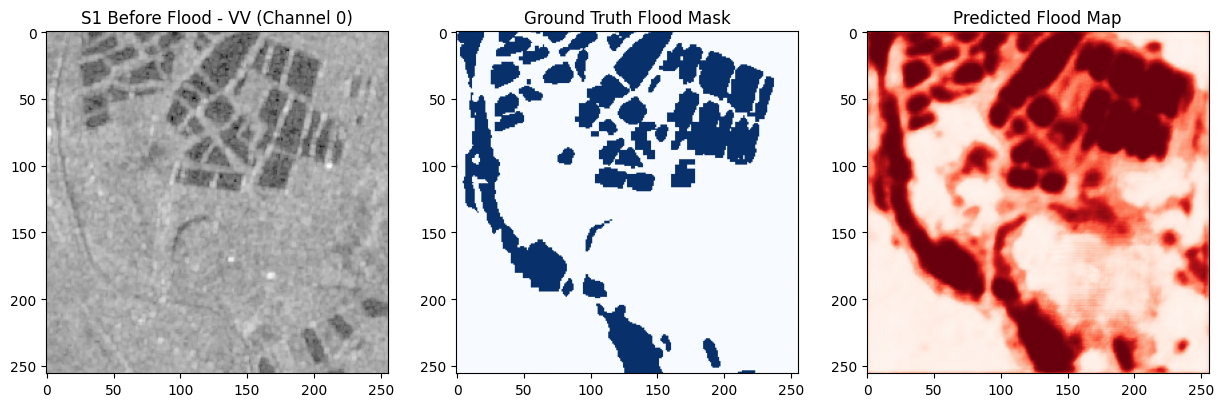

In [14]:
model.eval()

x_sample, y_sample = val_dataset[16]

x_in = x_sample.unsqueeze(0).to(device)
with torch.no_grad():
    pred = model(x_in).squeeze(0).squeeze(0)
    pred = torch.sigmoid(pred).cpu().numpy()

x_np = x_sample.numpy()
y_np = y_sample.numpy()[0]

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.title("S1 Before Flood - VV (Channel 0)")
plt.imshow(x_np[0], cmap="gray")

plt.subplot(1,3,2)
plt.title("Ground Truth Flood Mask")
plt.imshow(y_np, cmap="Blues")

plt.subplot(1,3,3)
plt.title("Predicted Flood Map")
plt.imshow(pred, cmap="Reds")

plt.show()
